# Dataset IMDB


**Autor:** Cleber de Jesus Salustiano  
**Matricula:** 20251mpca0170

## Configuracao

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "transformers": "transformers",
    "torch": "torch",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "tqdm": "tqdm",
}

missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    print("Instalando dependencias ausentes:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Todas as dependencias necessarias ja estao instaladas.")

Todas as dependencias necessarias ja estao instaladas.


In [2]:
import os
import random
import tarfile
import tempfile
import textwrap
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
from transformers import pipeline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 140)
plt.rcParams["figure.figsize"] = (6, 4)

print(f"PyTorch: {torch.__version__}")

PyTorch: 2.12.0


## Download e extracao da base IMDB

In [3]:
DATA_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
CACHE_ROOT = Path(tempfile.gettempdir()) / "hf_pipeline_imdb_cache"
ARCHIVE_PATH = CACHE_ROOT / "aclImdb_v1.tar.gz"
DATASET_DIR = CACHE_ROOT / "aclImdb"

CACHE_ROOT.mkdir(parents=True, exist_ok=True)

def safe_extract(tar: tarfile.TarFile, destination: Path) -> None:
    destination = destination.resolve()
    for member in tar.getmembers():
        member_path = (destination / member.name).resolve()
        if not str(member_path).startswith(str(destination)):
            raise RuntimeError(f"Arquivo inseguro no tar: {member.name}")
    tar.extractall(destination)

if not DATASET_DIR.exists():
    if not ARCHIVE_PATH.exists():
        print(f"Baixando base IMDB para {ARCHIVE_PATH}...")
        urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)
    else:
        print(f"Arquivo compactado ja existe em {ARCHIVE_PATH}.")

    print("Extraindo arquivos...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        safe_extract(tar, CACHE_ROOT)
else:
    print(f"Base ja extraida em {DATASET_DIR}.")

print("Diretorio da base:", DATASET_DIR)

Baixando base IMDB para /var/folders/gt/zkqdq7pj73nblw9yvwlq1_3c0000gn/T/hf_pipeline_imdb_cache/aclImdb_v1.tar.gz...


Extraindo arquivos...


Diretorio da base: /var/folders/gt/zkqdq7pj73nblw9yvwlq1_3c0000gn/T/hf_pipeline_imdb_cache/aclImdb


## Carregamento das resenhas

In [ ]:
N_PER_CLASS = 100

def read_review(path: Path) -> str:
    return path.read_text(encoding="utf-8", errors="replace").replace("<br />", " ").strip()

def load_imdb_split(split: str = "test", max_per_class: int | None = 100, seed: int = SEED) -> pd.DataFrame:
    rng = random.Random(seed)
    rows = []

    for label, target in [("neg", 0), ("pos", 1)]:
        folder = DATASET_DIR / split / label
        files = sorted(folder.glob("*.txt"))
        if max_per_class is not None:
            files = files.copy()
            rng.shuffle(files)
            files = files[:max_per_class]

        for file_path in tqdm(files, desc=f"Lendo {split}/{label}"):
            rating = int(file_path.stem.split("_")[-1])
            text = read_review(file_path)
            rows.append(
                {
                    "split": split,
                    "label": label,
                    "target": target,
                    "rating": rating,
                    "file": file_path.name,
                    "text": text,
                    "n_words": len(text.split()),
                }
            )

    df = pd.DataFrame(rows)
    return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

reviews = load_imdb_split("test", max_per_class=N_PER_CLASS)
print(f"Total de resenhas carregadas: {len(reviews):,}")
display(reviews.head())

Lendo test/neg:   0%|          | 0/100 [00:00<?, ?it/s]

Lendo test/pos:   0%|          | 0/100 [00:00<?, ?it/s]

Total de resenhas carregadas: 200


,split,label,target,rating,file,text,n_words
0,test,neg,0,3,28_3.txt,Rita Hayworth plays a Brooklyn nightclub dancer named Rusty who specializes in cheesecake chorus revues; she manages to get herself on t...,124
1,test,neg,0,1,2597_1.txt,"It's literally the Three Stooges all over again, without the charm. This show's nothing more than the worst slapstick. I'm surprised the...",102
2,test,neg,0,3,6542_3.txt,"When THE PUFFY CHAIR beckons, beware of its soft, colorful upholstery. The movie starts out quite well. Josh (Mark Duplass) and Emily (...",393
3,test,pos,1,10,10460_10.txt,There is no need for me to repeat the synopsis rendered by Glenn. The black and white rendition is even more powerful in portraying the ...,127
4,test,pos,1,7,5065_7.txt,"The reviews for RENDITION generally haven't been favorable, so I waited until it moved to the local discount theatre to see it. The film...",389


,quantidade,palavras_media,palavras_mediana,nota_media
label,,,,
neg,100,180.06,156.0,2.52
pos,100,217.84,176.0,8.76


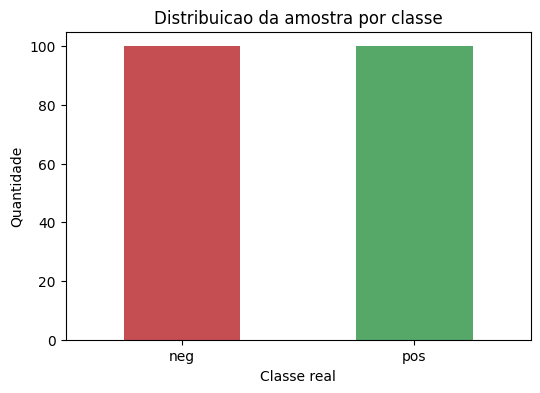

In [5]:
summary = reviews.groupby("label").agg(
    quantidade=("text", "size"),
    palavras_media=("n_words", "mean"),
    palavras_mediana=("n_words", "median"),
    nota_media=("rating", "mean"),
).round(2)

display(summary)

ax = reviews["label"].value_counts().sort_index().plot(kind="bar", color=["#c44e52", "#55a868"])
ax.set_title("Distribuicao da amostra por classe")
ax.set_xlabel("Classe real")
ax.set_ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

## Pipeline de analise de sentimento

In [6]:
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"

if torch.cuda.is_available():
    device = 0
    device_name = "cuda:0"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = "mps"
    device_name = "mps"
else:
    device = -1
    device_name = "cpu"

print(f"Modelo: {MODEL_NAME}")
print(f"Dispositivo usado pela pipeline: {device_name}")

sentiment_pipeline = pipeline(
    task="sentiment-analysis",
    model=MODEL_NAME,
    device=device,
)

Modelo: distilbert-base-uncased-finetuned-sst-2-english
Dispositivo usado pela pipeline: mps


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [7]:
def normalize_label(label: str) -> str:
    upper = label.upper()
    if "NEG" in upper or upper == "LABEL_0":
        return "neg"
    if "POS" in upper or upper == "LABEL_1":
        return "pos"
    raise ValueError(f"Rotulo inesperado retornado pela pipeline: {label}")

BATCH_SIZE = 16
texts = reviews["text"].tolist()
predictions = []

start = time.perf_counter()
for start_idx in tqdm(range(0, len(texts), BATCH_SIZE), desc="Classificando resenhas"):
    batch = texts[start_idx : start_idx + BATCH_SIZE]
    batch_predictions = sentiment_pipeline(
        batch,
        truncation=True,
        max_length=512,
        batch_size=BATCH_SIZE,
    )
    predictions.extend(batch_predictions)

elapsed = time.perf_counter() - start

reviews["pipeline_label"] = [prediction["label"] for prediction in predictions]
reviews["pred_label"] = [normalize_label(prediction["label"]) for prediction in predictions]
reviews["confidence"] = [prediction["score"] for prediction in predictions]
reviews["correct"] = reviews["label"] == reviews["pred_label"]

print(f"Tempo de inferencia: {elapsed:.1f}s")
print(f"Media por resenha: {elapsed / len(reviews):.3f}s")
display(reviews[["label", "pred_label", "confidence", "rating", "text"]].head())

Classificando resenhas:   0%|          | 0/13 [00:00<?, ?it/s]

Tempo de inferencia: 6.2s
Media por resenha: 0.031s


,label,pred_label,confidence,rating,text
0,neg,neg,0.997416,3,Rita Hayworth plays a Brooklyn nightclub dancer named Rusty who specializes in cheesecake chorus revues; she manages to get herself on t...
1,neg,neg,0.999772,1,"It's literally the Three Stooges all over again, without the charm. This show's nothing more than the worst slapstick. I'm surprised the..."
2,neg,neg,0.996087,3,"When THE PUFFY CHAIR beckons, beware of its soft, colorful upholstery. The movie starts out quite well. Josh (Mark Duplass) and Emily (..."
3,pos,pos,0.999668,10,There is no need for me to repeat the synopsis rendered by Glenn. The black and white rendition is even more powerful in portraying the ...
4,pos,pos,0.986409,7,"The reviews for RENDITION generally haven't been favorable, so I waited until it moved to the local discount theatre to see it. The film..."


## Metricas da analise

Acuracia na amostra: 90.00%

              precision    recall  f1-score   support

         neg       0.89      0.91      0.90       100
         pos       0.91      0.89      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



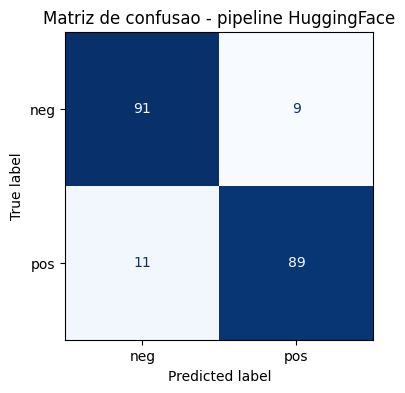

In [8]:
accuracy = accuracy_score(reviews["label"], reviews["pred_label"])
print(f"Acuracia na amostra: {accuracy:.2%}")
print()
print(classification_report(reviews["label"], reviews["pred_label"], target_names=["neg", "pos"]))

cm = confusion_matrix(reviews["label"], reviews["pred_label"], labels=["neg", "pos"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "pos"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Matriz de confusao - pipeline HuggingFace")
plt.show()

quantidade  confianca_media  nota_media
label pred_label                                         
neg   neg                 91            0.984       2.440
      pos                  9            0.865       3.333
pos   neg                 11            0.917       8.455
      pos                 89            0.984       8.798

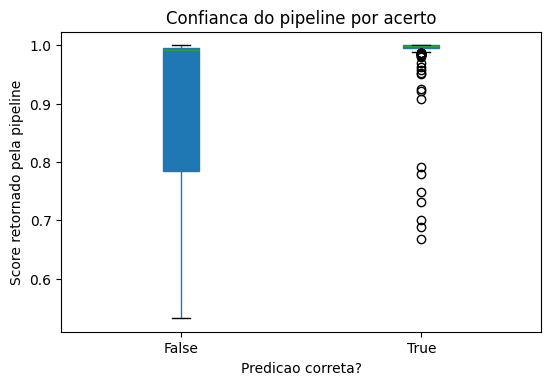

In [9]:
confidence_summary = reviews.groupby(["label", "pred_label"]).agg(
    quantidade=("text", "size"),
    confianca_media=("confidence", "mean"),
    nota_media=("rating", "mean"),
).round(3)

display(confidence_summary)

ax = reviews.boxplot(column="confidence", by="correct", grid=False, patch_artist=True)
ax.set_title("Confianca do pipeline por acerto")
ax.set_xlabel("Predicao correta?")
ax.set_ylabel("Score retornado pela pipeline")
plt.suptitle("")
plt.show()

## Exemplos qualitativos

In [10]:
def preview(text: str, width: int = 300) -> str:
    return textwrap.shorten(" ".join(text.split()), width=width, placeholder="...")

examples = reviews.copy()
examples["preview"] = examples["text"].map(preview)

print("Erros com maior confianca:")
errors = examples.loc[~examples["correct"]].sort_values("confidence", ascending=False)
display(errors[["label", "pred_label", "confidence", "rating", "preview"]].head(8))

print("\nAcertos com maior confianca:")
hits = examples.loc[examples["correct"]].sort_values("confidence", ascending=False)
display(hits[["label", "pred_label", "confidence", "rating", "preview"]].head(8))

Erros com maior confianca:


,label,pred_label,confidence,rating,preview
128,neg,pos,0.999671,4,"A wonderful semi-humorous homage to Expressionistic black and white films of folks like FW Murnau, Fritz Lang, Carl Dreyer, Marcel Carné..."
103,pos,neg,0.999271,7,This seemed to be a lackluster film to me that betrays a low budget with poor cinematography and not all that great of a job of editing....
7,pos,neg,0.998655,10,"This may not be regarded as a review on any film, but just a comment on a film I saw when I was a youngster. I remember coming home of a..."
6,neg,pos,0.997775,4,"Five years after the US Civil War, western folk are more concerned with the age old war between homesteaders and cattle ranchers. The ca..."
114,neg,pos,0.994981,3,Number 1 was really great summer popcorn fun. It was the modern Jaws. Number 2 is best summed up by Jeff Goldblum in the movie about bei...
147,pos,neg,0.994898,8,Remember that friend in college who always insisted you rent the weirdest movie possible? This is the movie he would have made if he'd h...
191,pos,neg,0.994756,9,"I cannot understand why this 1971 Hollywood production is currently only available through an Australian video company,but such is the u..."
165,neg,pos,0.994245,2,"More suspenseful, more subtle, much, much more disturbing...."



Acertos com maior confianca:


,label,pred_label,confidence,rating,preview
77,pos,pos,0.999872,10,Michael Jackson is amazing. This short film displays the absolute highest standard in music video and no-one will ever be able to out-be...
160,pos,pos,0.999851,9,"We all want to fall in love... The experience makes us feel completely alive, where every sense is heightened, every emotion is magnifie..."
92,pos,pos,0.999850,10,It is so nice to see Bruce Willis come down off his action throne and let us see that he really is a talented actor. He shines in this f...
41,pos,pos,0.999848,10,"One of the best,Lackawanna Blues Great movie,great cast,great music,this is one of those movies that is so good that when it is over you..."
166,pos,pos,0.999839,9,"I loved this film. It was so intelligent but it also had some great action sequences, without basing the movie solely around them. Quinn..."
126,pos,pos,0.999827,10,"Hilarious, clean, light-hearted, and quote-worthy. What else can you ask for in a film? This is my all-time, number one favorite movie. ..."
65,pos,pos,0.999823,10,"Whoever cast this movie was a genius, every character in it is perfect for their part, and they all do an absolutely excellent job in th..."
76,neg,neg,0.999818,1,What an utter disappointment. Forget this abysmal film and get hold of the TV series instead. What on earth were they doing making the A...


## Conclusao

A `pipeline` permite executar uma analise de sentimento completa com poucas linhas, pois combina preprocessamento, modelo Transformer e pos-processamento. Aqui usamos um modelo pronto, sem treinamento adicional, para classificar resenhas IMDB e comparar as predicoes com os rotulos reais da base.

In [11]:
n_total = len(reviews)
n_errors = int((~reviews["correct"]).sum())
print(f"Foram analisadas {n_total:,} resenhas do split de teste da base IMDB.")
print(f"Acuracia obtida: {accuracy:.2%}")
print(f"Erros encontrados: {n_errors:,}")
print("Para processar o split de teste inteiro, altere N_PER_CLASS para None e execute novamente.")

Foram analisadas 200 resenhas do split de teste da base IMDB.
Acuracia obtida: 90.00%
Erros encontrados: 20
Para processar o split de teste inteiro, altere N_PER_CLASS para None e execute novamente.
